<h1><center> <ins><b> A Complete Example of BOPMs with Real Stock Data </b></ins></center></h1>

# What we will do

We will attempt to calculate the price of a call and put option using our Binomial Option Pricing Models (BOPM), CRR and Chase ($\bar{p}=0.5$).

Firstly, we can easily access the data from [Yahoo Finance](https://finance.yahoo.com/quote/ASML/options/?date=1768521600). We can find the price of an option at this current time and rate free interest rate and the strike price and time to expiry of an option. <br>
We will calculate the volatility by looking at the past 10 years of data and calculating the std of log returns. <br>
We will then calculate the values of the option using our BOPMs for $n=100$ and $n=10^{8}$, then we can compare these values and the actual value of the option, using the Black-Scholes Model, to make a comparative analysis with a plot to aid in visualising this.

In [1]:
# Import Libraries and BOPMs
import numpy as np
import pandas as pd
from scipy import stats
import yfinance as yf
import ipynb
from ipynb.fs.full.BOPM_Models import BOPM_CRR, BOPM_Chance
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
%matplotlib inline
plt.style.use('fivethirtyeight')
import datetime

In [2]:
# Quickly define formulae to calculate value of options using Black-Scholes
# Refer to Black Scholes Deep Dive for more information
# Define d1, d2, n(x)
def d1(S,K,r,q,sigma,T,t):
    d1=(np.log(S/K)+((r-q+((sigma**2)/2))*(T-t)))/(sigma*np.sqrt((T-t)))
    return d1
def d2(S,K,r,q,sigma,T,t):
    d2=(np.log(S/K)+(r-q-((sigma**2)/2))*(T-t))/(sigma*np.sqrt((T-t)))    
    return d2
def n(x):
    ans=np.exp(-(x**2)/2)/(np.sqrt(2*np.pi))   
    return ans
# Define Option Values for the 4 types of options
def BSC(S,K,r,q,sigma,T,t):
    OVEC= (S*(stats.norm.cdf(d1(S,K,r,q,sigma,T,t)))*(np.exp(-q*(T-t))))-(K*(stats.norm.cdf(d2(S,K,r,q,sigma,T,t)))*(np.exp(-r*(T-t))))
    return OVEC
def BSP(S,K,r,q,sigma,T,t):
    OVEP= -(S*(stats.norm.cdf(-(d1(S,K,r,q,sigma,T,t))))*(np.exp(-q*(T-t))))+(K*(stats.norm.cdf(-(d2(S,K,r,q,sigma,T,t))))*(np.exp(-r*(T-t))))
    return OVEP

In [3]:
# Initial Derivative Parameters from ASML Option data
S = 732.22
K = 730
r = 0.046
q = 0
T = ((datetime.date(2027,1,1)-datetime.date(2025,3,7)).days+1)/365
t = 0
p = 0.5
EC_Value = 171.0
EP_Value = 110.0

In [4]:
# Download past 10 years of stock data for ASML to estimate volatility
end_date = '2025-02-07'
start_date = pd.to_datetime(end_date)-pd.DateOffset(365*10)
df = yf.download(tickers='ASML',
                 auto_adjust=False,
                 start=start_date,
                 end=end_date).stack()
df.columns = df.columns.str.lower()
df = df['adj close']

# Calculate log returns each day
ret = np.log(df) - np.log(df.shift(1))
# Calculate annualised volatility for 252 trading days
sigma = ret.std() * np.sqrt(252)

[*********************100%***********************]  1 of 1 completed


In [5]:
# Calculate our option values using BS
BS_Call = BSC(S,K,r,q,sigma,T,t)
BS_Put = BSP(S,K,r,q,sigma,T,t)

# Calculate our option values using BOPMs with 100 time steps
n=100
CRR1_Call = BOPM_CRR(S, K, r, q, sigma, T, n, Option_Type='call')
Chance1_Call = BOPM_Chance(S, K, r, q, sigma, T, n, p, Option_Type='call')
CRR1_Put = BOPM_CRR(S, K, r, q, sigma, T, n, Option_Type='put')
Chance1_Put = BOPM_Chance(S, K, r, q, sigma, T, n, p, Option_Type='put')
# Calculate our option values using BOPMs with 1000000 time steps
n=1e6
CRR2_Call = BOPM_CRR(S, K, r, q, sigma, T, n, Option_Type='call')
Chance2_Call = BOPM_Chance(S, K, r, q, sigma, T, n, p, Option_Type='call')
CRR2_Put = BOPM_CRR(S, K, r, q, sigma, T, n, Option_Type='put')
Chance2_Put = BOPM_Chance(S, K, r, q, sigma, T, n, p, Option_Type='put')

# Calculate relative errors for large n
RE1 = 100*(abs(CRR2_Call-EC_Value)/EC_Value)
RE2 = 100*(abs(Chance2_Call-EC_Value)/EC_Value)
RE3 = 100*(abs(BS_Call-EC_Value)/EC_Value)
RE4 = 100*(abs(CRR2_Put-EP_Value)/EP_Value)
RE5 = 100*(abs(Chance2_Put-EP_Value)/EP_Value)
RE6 = 100*(abs(BS_Put-EP_Value)/EP_Value)

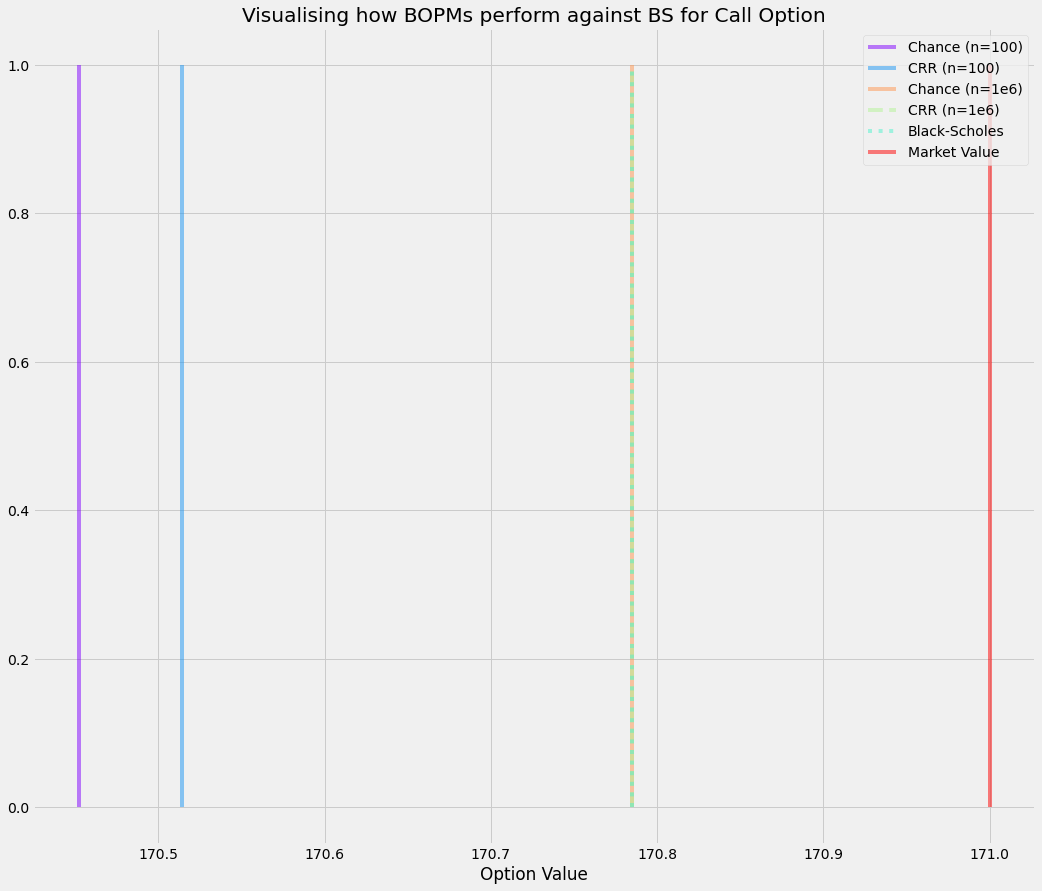

In [6]:
# Plotting to visualise call option values
colour = list(cm.rainbow(np.linspace(0, 1, 6)))
plt.figure(figsize=(16,14))
plt.vlines(Chance1_Call, ymin=0,ymax= 1,linestyle='solid',colors=colour[0],alpha=0.5,label = 'Chance (n=100)')
plt.vlines(CRR1_Call, ymin=0,ymax= 1,linestyle='solid',colors=colour[1],alpha=0.5,label = 'CRR (n=100)')
plt.vlines(Chance2_Call, ymin=0,ymax= 1,linestyle='solid',colors=colour[4],alpha=0.5,label = 'Chance (n=1e6)')
plt.vlines(CRR2_Call, ymin=0,ymax= 1,linestyle='dashed',colors=colour[3],alpha=0.5,label = 'CRR (n=1e6)')
plt.vlines(BS_Call, ymin=0,ymax= 1,linestyle='dotted',colors=colour[2],alpha=0.5,label = 'Black-Scholes')
plt.vlines(EC_Value, ymin=0,ymax= 1,linestyle='solid',colors=colour[5],alpha=0.5,label = 'Market Value')
plt.xlabel("Option Value")
plt.title("Visualising how BOPMs perform against BS for Call Option")
plt.legend()
plt.show()

In [7]:
# Relative Errors

print(f'The Average Relative Error of CRR(n=1e6) is {RE1:0.5f}%')
print(f'The Average Relative Error of Chance(n=1e6) is {RE2:0.5f}%')
print(f'The Average Relative Error of Black-Scholes is {RE3:0.5f}%')

The Average Relative Error of CRR(n=1e6) is 0.12567%
The Average Relative Error of Chance(n=1e6) is 0.12568%
The Average Relative Error of Black-Scholes is 0.12565%


### Again, as proved and mentioned in other notebooks, we can see how for large $n$, both of our BOPMs converge to the Black-Scholes Model. Most notably though, we can see that our predicted prices are only ~0.13% off the market price which tells us that our implementation has been very accurate.

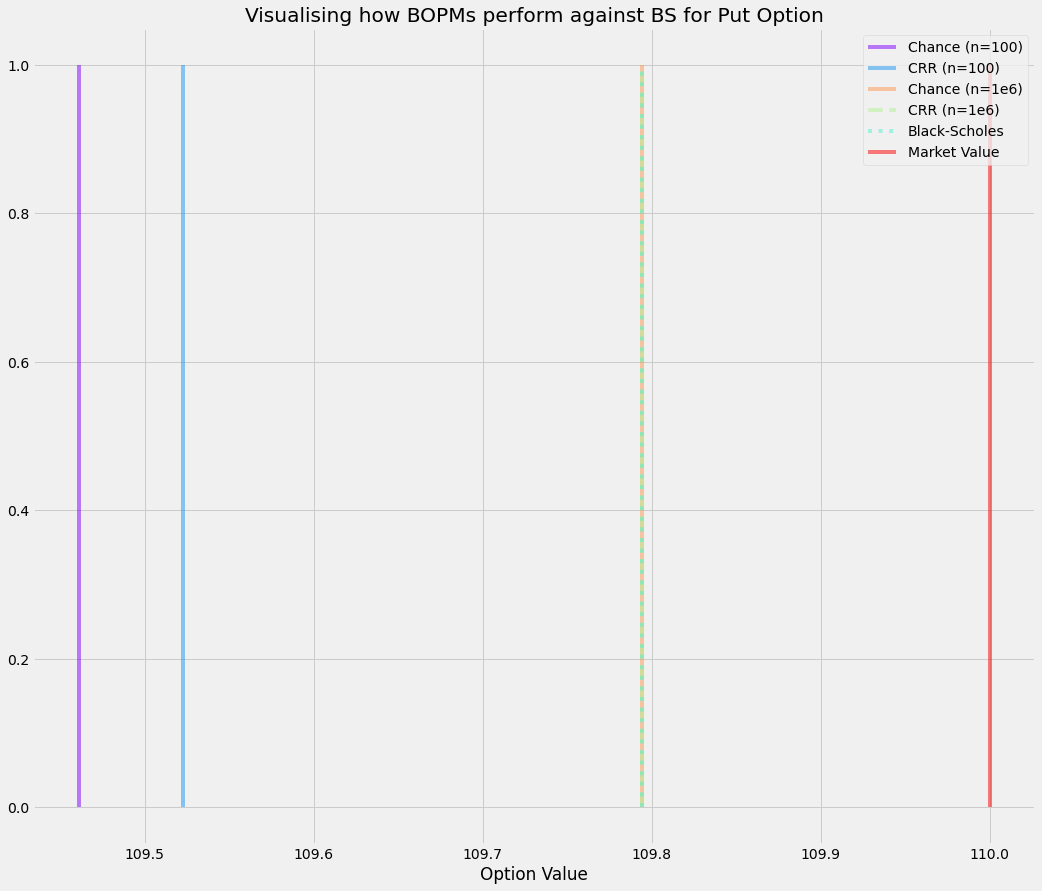

In [8]:
# Plotting to visualise put option values
colour = list(cm.rainbow(np.linspace(0, 1, 6)))
plt.figure(figsize=(16,14))
plt.vlines(Chance1_Put, ymin=0,ymax= 1,linestyle='solid',colors=colour[0],alpha=0.5,label = 'Chance (n=100)')
plt.vlines(CRR1_Put, ymin=0,ymax= 1,linestyle='solid',colors=colour[1],alpha=0.5,label = 'CRR (n=100)')
plt.vlines(Chance2_Put, ymin=0,ymax= 1,linestyle='solid',colors=colour[4],alpha=0.5,label = 'Chance (n=1e6)')
plt.vlines(CRR2_Put, ymin=0,ymax= 1,linestyle='dashed',colors=colour[3],alpha=0.5,label = 'CRR (n=1e6)')
plt.vlines(BS_Put, ymin=0,ymax= 1,linestyle='dotted',colors=colour[2],alpha=0.5,label = 'Black-Scholes')
plt.vlines(EP_Value, ymin=0,ymax= 1,linestyle='solid',colors=colour[5],alpha=0.5,label = 'Market Value')
plt.xlabel("Option Value")
plt.title("Visualising how BOPMs perform against BS for Put Option")
plt.legend()
plt.show()

In [9]:
# Relative Errors

print(f'The Average Relative Error of CRR(n=1e6) is {RE4:0.5f}%')
print(f'The Average Relative Error of Chance(n=1e6) is {RE5:0.5f}%')
print(f'The Average Relative Error of Black-Scholes is {RE6:0.5f}%')

The Average Relative Error of CRR(n=1e6) is 0.18722%
The Average Relative Error of Chance(n=1e6) is 0.18724%
The Average Relative Error of Black-Scholes is 0.18720%


### Again, as proved and mentioned in other notebooks, we can see how for large $n$, both of our BOPMs converge to the Black-Scholes Model. Most notably though, we can see that our predicted prices are only ~0.19% off the market price which tells us that our implementation has been very accurate.

# Conclusion

We have managed to successfully model the price of both a European Call and Put Option using our 2 Binomial Option Pricing Models (CRR and Chance). And for large $n$ we have confirmed that it converges to the Black-Scholes Model value and we have shown that is it extremely close to the true market value of the option.